## The ARMA Model

The ARMA model is a simple combination of the AR and MA models. The idea behind 
combining the AR and MA models into one model is that the models together are more 
performant than one model. The development over time of one variable can follow 
multiple processes at the same time.

The AR model tries to 
predict the future by `multiplying past values by a coefficient`. This AR process is based 
on the presence of autocorrelation: the target variable’s present value is correlated to a 
past value. The MA model does not use past values of the target variable to predict its 
future, but rather uses the `error of past predictions` as an impulse for forecasted values.

###  Predicting Sunspots Using ARMA
You will be working with the sunspot dataset, 
a relatively famous dataset that contains very long historical observations of the number 
of spots on the sun. 

In [5]:
import pandas as pd

data=pd.read_csv('../database/Sunspots.csv', usecols=[1,2])

In [6]:
data.head()

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7


In [7]:
# Aggregating the sunspot data to yearly data
data['year'] = data.Date.apply(lambda x: x[:4]) # x[:4] uses Python string slicing to grab the first 4 characters of that value (for example, extracting "2026" from "2026-08-14")
data = data[['Monthly Mean Total Sunspot Number',  
'year']].groupby('year').sum()
data.head()

,Monthly Mean Total Sunspot Number
year,
1749,1618.5
1750,1668.0
1751,953.3
1752,956.0
1753,613.5


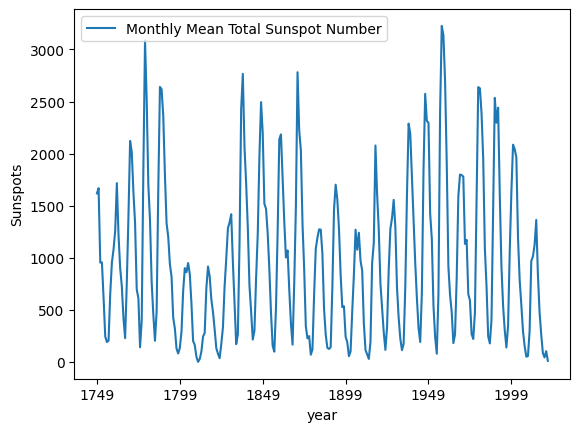

In [8]:
# Plotting the yearly sunspot data
import matplotlib.pyplot as plt

ax = data.plot()
ax.set_ylabel('Sunspots')
plt.show()

In [9]:
data.tail()

,Monthly Mean Total Sunspot Number
year,
2017,261.8
2018,84.1
2019,43.0
2020,103.5
2021,10.4


Looking at this plot, the pattern is already strikingly clear: high peaks on regular 
intervals. Let’s see how to use the ARMA model to capture this pattern and make 
predictions for the future. The first step, as always, is to verify whether the data is 
stationary or not.

In [10]:
# Applying the ADF test to the sunspot yearly totals
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['Monthly Mean Total Sunspot Number'])
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-2.6538922261225757), np.float64(0.0823623525803937), 8, 264, {'1%': np.float64(-3.455365238788105), '5%': np.float64(-2.8725510317187024), '10%': np.float64(-2.5726375763314966)}, np.float64(3654.5652190879646))
not stationary


The result that we obtain when applying this test is unexpected: the ADF test 
tells us that the data is `not stationary`. In this case, the intuitive decision would be to 
assume stationarity, while the ADF tells you not to. A choice has to be made.
For now, let’s keep it the easiest possible and stay with the original data.
Now the second thing to look at is the autocorrelation function (ACF) and the partial 
autocorrelation function (PACF). Remember that the ACF and PACF plots can help you 
to define whether we are working with AR or MA processes.

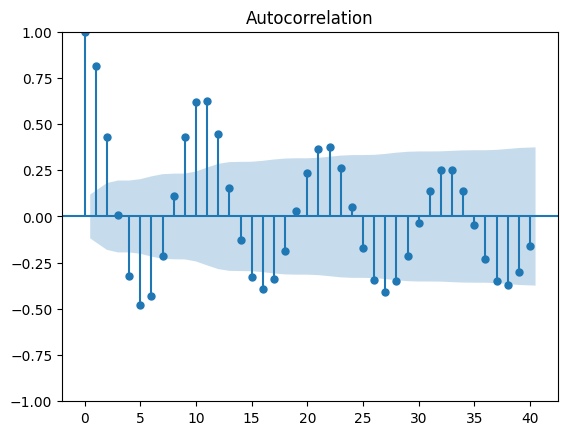

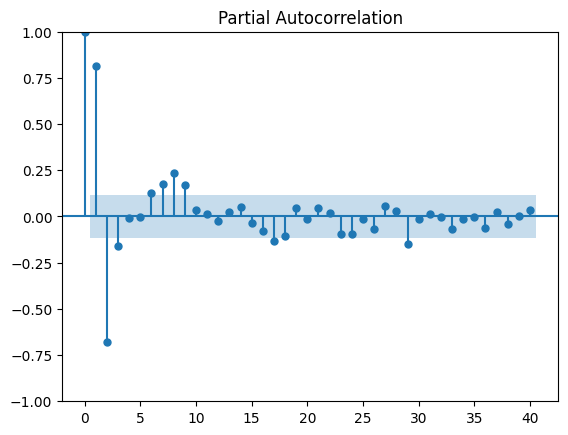

In [11]:
# Creating the ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plot_acf(data['Monthly Mean Total Sunspot Number'], lags=40)
plot_pacf(data['Monthly Mean Total Sunspot Number'], lags=40)
plt.show()

This means that in the sunspot case, you have a strong indicator for observing an AR 
pattern: there is exponential decay in the PACF, together with switching from negative to 
positive. There is no real evidence for an MA process when looking at those plots.

recall the indicators on which model to use. Check previous notes or check page 94.

### Fitting an ARMA(p,_,q) Model

In the ARMA(p,q) model, p and q are the 
hyperparameters that you must decide on using plots, performance metrics, and more.

To get started, let’s see how to fit an ARMA(1,1) model in Python. An ARMA(1,1) 
model means an ARMA model with an AR component with order 1 and an MA 
component with order 1.


0.7628968971292776


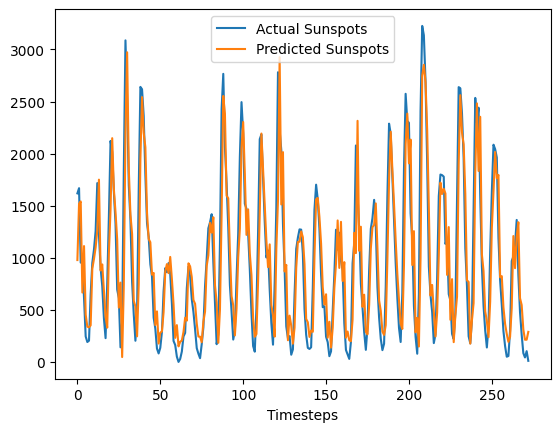

In [13]:
# Fitting the ARMA(1,1) model
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA

# Forecast the first ARMA(1,1) model
mod = ARIMA(list(data['Monthly Mean Total Sunspot Number']), order=(1,0,1))
res = mod.fit()
pred = res.predict()
## NOTE: we didnt split the data so we are not forcasting. We will see how well the model fits the train data (entire data)
print(r2_score(data, pred))
plt.plot(list(data['Monthly Mean Total Sunspot Number']))
plt.plot(pred)
plt.legend(['Actual Sunspots', 'Predicted Sunspots'])
plt.xlabel('Timesteps')
plt.show()

An additional KPI that can help us evaluate model fit is to look at the residuals of 
our model. If a model has a good fit, we will generally observe that the residuals follow 
a normal distribution. If we find the opposite, our model is generally missing out on 
important information. ***CHECK PAGE 96***

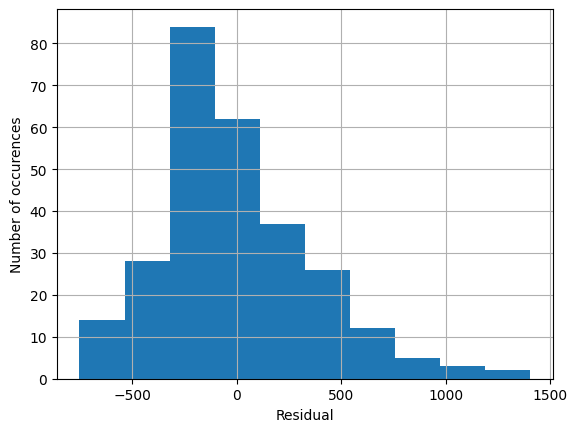

In [14]:
ax = pd.Series(res.resid).hist()
ax.set_ylabel('Number of occurences')
ax.set_xlabel('Residual')
plt.show()

We can observe visually that the histogram of the residuals is not following the bell- 
shaped curve that is the normal distribution. This means that there are probably some 
lags to be added, which is logical: you already know that the sunspot data has an 11-year 
seasonality, and for now there is only one lagged period (1 year back) included in the 
model

In [15]:
# Obtaining the summary table of your model’s fit
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  273
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2001.158
Date:                Fri, 14 Aug 2026   AIC                           4010.316
Time:                        12:00:28   BIC                           4024.754
Sample:                             0   HQIC                          4016.112
                                - 273                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        977.9319    154.350      6.336      0.000     675.411    1280.453
ar.L1          0.7224      0.051     14.192      0.000       0.623       0.822
ma.L1          0.5246      0.053      9.964      0.000       0.421       0.628
sigma2      1.355e+05   1.08e+04     12.552      0.000    1.14e+05    1.57e+05
===================================================================================
Ljung-Box (L1) (Q):                   8.45   Jarque-Bera (JB):                43.41
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.43   Skew:                             0.81
Prob(H) (two-sided):                  0.09   Kurtosis:                         4.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Important pieces of information that we can get from this table are the estimates of 
the `coefficients` and the `corresponding p-values`.

Basically, those estimates 
state that we can predict a future data point, by filling in the ARMA formula using 
the const as c, the ar.L1 as coefficient φi (phi), and the ma.L1 as coefficient θi (tetha). 

For each coefficient, the summary table shows 
a hypothesis test that tells us whether the coefficient is `significantly different from zero`. If a coefficient were to be zero, this would mean that it is not useful to include the parameter. Yet, if a hypothesis test proves that a coefficient is significantly different from 
zero, this means that it is useful to add the coefficient in your model. This helps you in 
deciding which order to use for your ARMA forecast.

** The p-value must be smaller than 0.05 to prove that the coefficient is significantly different from zero **

### Grid Search: Tuning for Predictive Performance

In the ARMA model, two hyperparameters need to be optimized at the same time: p and q. The goal of a grid search for hyperparameter optimization is to make the task of choosing hyperparameters.

In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

data_array = data.values

avg_errors = []

for p in range(13):
    for q in range(13):
        errors = []
        tscv = TimeSeriesSplit(test_size=10)

        for train_index, test_index in tscv.split(data_array):
            X_train = data_array[train_index]
            X_test = data_array[test_index]
            X_test_orig = X_test.copy()
            fcst = []

            for step in range(10):
                try:
                    mod = ARIMA(X_train, order=(p, 0, q))
                    res = mod.fit()

                    # Convert forecast from array to scalar
                    forecast = res.forecast(steps=1)[0]
                    fcst.append(forecast)

                except Exception as e:
                    print(f"Error for p={p}, q={q}, step={step}: {e}")

                    # Use a scalar here as well
                    fcst.append(np.nan)

                # Add actual observation to training data
                X_train = np.concatenate(
                    (X_train, X_test[0:1, :])
                )

                # Remove first test observation
                X_test = X_test[1:] ## so that by the next iteration it does not repeat the same datapoint sent to x_train

            # Convert actual values to 1D
            y_true = X_test_orig.ravel()

            # Convert forecasts to 1D
            y_pred = np.array(fcst)

            # Don't calculate R² if a model failed
            if np.isnan(y_pred).any():
                errors.append(np.nan)
            else:
                errors.append(r2_score(y_true, y_pred))

        pq_result = [p, q, np.nanmean(errors)]
        print(pq_result)
        avg_errors.append(pq_result)

[0, 0, np.float64(-0.31165077214903275)]
[0, 1, np.float64(0.489727835406747)]
[0, 2, np.float64(0.6602548491626004)]
[0, 3, np.float64(0.7132354965803402)]
[0, 4, np.float64(0.7623539836171698)]
[0, 5, np.float64(0.7696766908731814)]
[0, 6, np.float64(0.7672843438889982)]
[0, 7, np.float64(0.7542262202822039)]
[0, 8, np.float64(0.7722373374929798)]
[0, 9, np.float64(0.7711111622104565)]
[0, 10, np.float64(0.7390356783020187)]
[0, 11, np.float64(0.7870930536477729)]
[0, 12, np.float64(0.7633277328062684)]
[1, 0, np.float64(0.625329062332526)]
[1, 1, np.float64(0.7218930597394646)]
[1, 2, np.float64(0.7360515855903712)]
[1, 3, np.float64(0.7564985597401506)]
[1, 4, np.float64(0.7471351455398951)]
[1, 5, np.float64(0.7661635906782983)]
[1, 6, np.float64(0.7699635656804013)]
[1, 7, np.float64(0.7626274079783221)]
[1, 8, np.float64(0.7609087580688578)]
[1, 9, np.float64(0.7763557838069745)]
[1, 10, np.float64(0.7870880708272734)]
[1, 11, np.float64(0.7981339390820537)]
[1, 12, np.float64(0

In [18]:
avg_errors

[[0, 0, np.float64(-0.31165077214903275)],
 [0, 1, np.float64(0.489727835406747)],
 [0, 2, np.float64(0.6602548491626004)],
 [0, 3, np.float64(0.7132354965803402)],
 [0, 4, np.float64(0.7623539836171698)],
 [0, 5, np.float64(0.7696766908731814)],
 [0, 6, np.float64(0.7672843438889982)],
 [0, 7, np.float64(0.7542262202822039)],
 [0, 8, np.float64(0.7722373374929798)],
 [0, 9, np.float64(0.7711111622104565)],
 [0, 10, np.float64(0.7390356783020187)],
 [0, 11, np.float64(0.7870930536477729)],
 [0, 12, np.float64(0.7633277328062684)],
 [1, 0, np.float64(0.625329062332526)],
 [1, 1, np.float64(0.7218930597394646)],
 [1, 2, np.float64(0.7360515855903712)],
 [1, 3, np.float64(0.7564985597401506)],
 [1, 4, np.float64(0.7471351455398951)],
 [1, 5, np.float64(0.7661635906782983)],
 [1, 6, np.float64(0.7699635656804013)],
 [1, 7, np.float64(0.7626274079783221)],
 [1, 8, np.float64(0.7609087580688578)],
 [1, 9, np.float64(0.7763557838069745)],
 [1, 10, np.float64(0.7870880708272734)],
 [1, 11, np.

In [19]:
avg_errors = pd.DataFrame(avg_errors)
avg_errors.columns = ['p', 'q', 'error']
result = avg_errors.pivot(index='p', columns='q')

In [21]:
result

error                                                              \
q         0         1         2         3         4         5         6    
p                                                                          
0  -0.311651  0.489728  0.660255  0.713235  0.762354  0.769677  0.767284   
1   0.625329  0.721893  0.736052  0.756499  0.747135  0.766164  0.769964   
2   0.779719  0.789059  0.790293  0.790473  0.784811  0.784022  0.800632   
3   0.790130  0.785829  0.786056  0.824038  0.820248  0.814362  0.813608   
4   0.789560  0.786152  0.785721  0.791883  0.816061  0.814064  0.813238   
5   0.786136  0.782538  0.787439  0.796339  0.814501  0.824059  0.815524   
6   0.782794  0.811059  0.812476  0.880315  0.786399  0.823694  0.818628   
7   0.784901  0.805036  0.782286  0.766143  0.829932  0.823511  0.821214   
8   0.800899  0.812367  0.813653  0.745621  0.800419  0.800786  0.824839   
9   0.818473  0.816441  0.816341  0.815357  0.797510  0.811617  0.807677   
10  0.816209  0.815774  0.816712  0.814567  0.803889  0.799561  0.824686   
11  0.816017  0.814661  0.816142  0.811675  0.812499  0.804587  0.798525   
12  0.813970  0.813360  0.814564  0.823449  0.804982  0.824962  0.809992   

                                                                
q         7         8         9         10        11        12  
p                                                               
0   0.754226  0.772237  0.771111  0.739036  0.787093  0.763328  
1   0.762627  0.760909  0.776356  0.787088  0.798134  0.783582  
2   0.802100  0.795428  0.823243  0.823094  0.821181  0.818975  
3   0.812400  0.810667  0.821996  0.819161  0.819920  0.814970  
4   0.810190  0.813013  0.804435  0.805132  0.818583  0.814537  
5   0.821659  0.819926  0.822320  0.808549  0.809868  0.832168  
6   0.818905  0.817007  0.818786  0.823817  0.824582  0.813791  
7   0.823184  0.818324  0.830963  0.818496  0.818730  0.814990  
8   0.825399  0.814308  0.829451  0.823718  0.827780  0.813313  
9   0.784582  0.816233  0.836936  0.822347  0.813644  0.826236  
10  0.827354  0.807566  0.840280  0.832872  0.805393  0.789140  
11  0.815920  0.811845  0.837604  0.813599  0.813890  0.783353  
12  0.815453  0.812104  0.831937  0.815910  0.802630  0.791516

`p=10 and q=9` is the best optimized parameters. I know there are others with higher, but those ones have NaNs involved in the fcst which was skipped and others taken as average. 

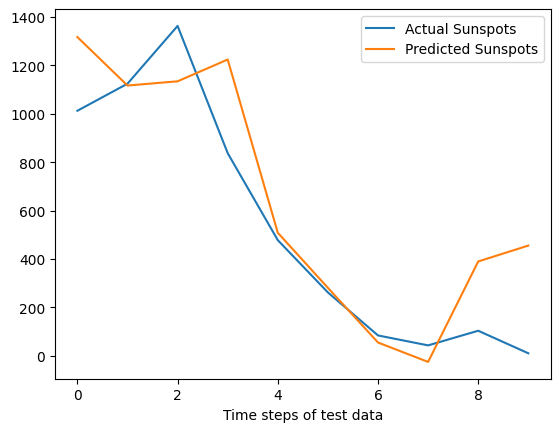

In [22]:
# Showing the test prediction of the final model
data_array = data.values
X_train, X_test = data_array[:-10], data_array[-10:]
X_test_orig = X_test
fcst = []

for step in range(10):
    mod = ARIMA(X_train, order=(10,0,9))
    res = mod.fit()
    fcst.append(res.forecast(steps=1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]
    
plt.plot(X_test_orig)
plt.plot(fcst)
plt.legend(['Actual Sunspots', 'Predicted Sunspots'])
plt.xlabel('Time steps of test data')
plt.show()

### Key Takeaways
* The ARMA model is the combination of the autoregressive model 
and the Moving Average model.
* The hyperparameters of ARMA are p and q: p for the autoregressive 
order and q for the moving average order.
* A grid search is a common tool for optimizing the choice of 
hyperparameters. It can be combined with cross-validation to yield 
more reliable error estimates.
* You can use the distribution of residuals to evaluate the fit of a model. 
If the residuals do not follow a normal distribution, there is generally 
something wrong with the model specification.
* You can use the model summary to look at detailed indicators of 
model fit. You can also find the estimates of model coefficients and a 
hypothesis test that tests the model coefficients against zero